In [2]:
# Uncomment if required
# %pip install geopandas osmnx folium minisom numpy matplotlib shapely pyproj 
# %pip install entropy
# %pip install scipy

# 1. Import libraries

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
from shapely.geometry import box
import matplotlib.pyplot as plt

/Volumes/Hercules/Developer/multilayer-priority/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 2. Read map

In [2]:
city = "Porto"

In [3]:
raw_grid_gdf = gpd.read_file(f"../data/multi_layers/{city}_multi_layer_all_scenarios.geojson")

In [4]:
raw_grid_gdf.head(2)  # Display the first 5 rows of the GeoDataFrame

,hex_id,response_value,risk_value,vulnerability_s1_value,vulnerability_s2_value,vulnerability_s3_value,vulnerability_s4_value,gini_value,income_value,geometry
0,h_581,0.131592,2.909383,0.401248,0.723351,0.507541,0.636852,0.433,13150,"POLYGON ((-8.63215 41.14512, -8.63137 41.14478..."
1,h_755,0.183663,2.176694,0.094273,0.289571,0.289247,0.367604,0.433,13150,"POLYGON ((-8.64304 41.14715, -8.64271 41.147, ..."


# 3. Normalize values

Values of mitigation and vulnerability are already normalized, but we need to normalize the rest of the values using the min-max method.

In [5]:
# Create a copy of the grid GeoDataFrame and replace the risk_value, gini_value, and income_value with its normalized values
grid_gdf = raw_grid_gdf.copy()
grid_gdf['risk_value'] = grid_gdf['risk_value'].apply(lambda x: (x - grid_gdf['risk_value'].min()) / (grid_gdf['risk_value'].max() - grid_gdf['risk_value'].min()))
grid_gdf['gini_value'] = grid_gdf['gini_value'].apply(lambda x: (x - grid_gdf['gini_value'].min()) / (grid_gdf['gini_value'].max() - grid_gdf['gini_value'].min()))
grid_gdf['income_value'] = grid_gdf['income_value'].apply(lambda x: (x - grid_gdf['income_value'].min()) / (grid_gdf['income_value'].max() - grid_gdf['income_value'].min()))

grid_gdf.describe()  # Display the summary statistics of the GeoDataFrame

,response_value,risk_value,vulnerability_s1_value,vulnerability_s2_value,vulnerability_s3_value,vulnerability_s4_value,gini_value,income_value
count,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000,2965.000000
mean,0.277662,0.332180,0.153914,0.506292,0.388063,0.523392,0.445265,0.356666
std,0.209572,0.225531,0.153920,0.176655,0.127923,0.149075,0.321978,0.317923
min,0.000000,0.000000,0.000000,0.002468,0.000000,0.000000,0.000000,0.000000
25%,0.122187,0.156481,0.065419,0.390820,0.296696,0.439640,0.300000,0.154039
50%,0.214866,0.264620,0.099245,0.484729,0.386894,0.516085,0.366667,0.247969
75%,0.396495,0.450584,0.150799,0.591333,0.484519,0.606642,0.722222,0.457392
max,1.000000,1.000000,0.892001,1.010731,0.691446,0.985014,1.000000,1.000000


# 4. Compute the weighs of the indicators

In [7]:
# Function to calculate weights using entropy method
def calculate_entropy_weights(data):
    # Normalize the data (0-1)
    normalized_data = (data - data.min()) / (data.max() - data.min())

    # Calculate entropy for each feature
    n_samples = len(normalized_data)
    entropies = {}
    weights = {}

    for column in normalized_data.columns:
        # Calculate probability distribution
        column_sum = normalized_data[column].sum()
        if column_sum == 0:
            # Avoid division by zero
            probabilities = normalized_data[column]
        else:
            probabilities = normalized_data[column] / column_sum

        # Calculate entropy manually using Shannon's formula
        # Filter out zeros to avoid log(0) issues
        valid_probs = probabilities[probabilities > 0]
        if len(valid_probs) > 0:
            # Calculate Shannon entropy: -sum(p_i * log(p_i))
            entropy_value = -np.sum(valid_probs * np.log(valid_probs))

            # Normalize by log(n) to get relative entropy in [0,1]
            max_entropy = np.log(n_samples)
            if max_entropy > 0:  # Avoid division by zero
                relative_entropy = entropy_value / max_entropy
            else:
                relative_entropy = 0
        else:
            relative_entropy = 0

        entropies[column] = relative_entropy
        # Calculate weight as 1 - normalized entropy
        weights[column] = 1 - relative_entropy

    # Normalize weights to sum to 1
    weight_sum = sum(weights.values())
    if weight_sum > 0:  # Avoid division by zero
        weights = {col: weight / weight_sum for col, weight in weights.items()}

    return weights


# Calculate weights for core indicators
core_data = grid_gdf[["response_value", "vulnerability_s2_value", "risk_value"]].copy()
core_weights = calculate_entropy_weights(core_data)
print("Entropy core weights (using entropy library):", core_weights)

# Calculate weights for equity indicators
# First invert where higher means less vulnerable
equity_data = grid_gdf[["gini_value", "income_value"]].copy()
equity_data["gini_value"] = 1 - equity_data["gini_value"]  # inverse relation
equity_data["income_value"] = 1 - equity_data["income_value"]  # poor = high score
equity_weights = calculate_entropy_weights(equity_data)
print("Entropy equity weights (using entropy library):", equity_weights)

Entropy core weights (using entropy library): {'response_value': 0.49571914216060575, 'vulnerability_s2_value': 0.11516028456455817, 'risk_value': 0.38912057327483607}
Entropy equity weights (using entropy library): {'gini_value': 0.5496334738710956, 'income_value': 0.45036652612890443}


In [8]:
all_data = grid_gdf[
    [
        "response_value",
        "vulnerability_s2_value",
        "risk_value",
        "gini_value",
        "income_value",
    ]
].copy()
# Calculate weights for all indicators
all_weights = calculate_entropy_weights(all_data)
print("Entropy all weights (using entropy library):", all_weights)
# Create a new column for the weighted sum of the core indicators
grid_gdf["core_weighted_sum"] = (
    grid_gdf["response_value"] * all_weights["response_value"]
    + grid_gdf["vulnerability_s2_value"] * all_weights["vulnerability_s2_value"]
    + grid_gdf["risk_value"] * all_weights["risk_value"]
    + grid_gdf["gini_value"] * all_weights["gini_value"]
    + grid_gdf["income_value"] * all_weights["income_value"]
)
# Create a new column for the weighted sum of the equity indicators

Entropy all weights (using entropy library): {'response_value': 0.2098227018245593, 'vulnerability_s2_value': 0.04874381478371911, 'risk_value': 0.16470279857297762, 'gini_value': 0.25176670757866726, 'income_value': 0.3249639772400767}


In [10]:
core_data.describe()  # Display the summary statistics of the core indicators

,response_value,vulnerability_value,risk_value
count,6569.000000,6569.000000,6569.000000
mean,0.279292,0.185456,0.509069
std,0.168805,0.150811,0.272584
min,0.000026,0.003500,0.000000
25%,0.152238,0.077910,0.325366
50%,0.262407,0.136859,0.404968
75%,0.369752,0.251718,0.717996
max,1.000000,0.999078,1.000000


# 5. Compute the composite risk index (CRI)

In [9]:
# Apply weights to calculate scores
core_data_norm = (core_data - core_data.min()) / (core_data.max() - core_data.min())
all_data_norm = (all_data - all_data.min()) / (all_data.max() - all_data.min())
core_score = core_data_norm.mul(pd.Series(core_weights)).sum(axis=1)
all_score = all_data_norm.mul(pd.Series(all_weights)).sum(axis=1)

equity_data_norm = (equity_data - equity_data.min()) / (equity_data.max() - equity_data.min())
equity_score = equity_data_norm.mul(pd.Series(equity_weights)).sum(axis=1)

# Calculate priority with equity boost
gamma = 0.4  # policy dial: 0-1
priority = core_score * (1 + gamma * equity_score)

# Normalize to 0-1 scale
priority_norm = (priority - priority.min()) / (priority.max() - priority.min())
all_score_norm = (all_score - all_score.min()) / (all_score.max() - all_score.min())
core_score_norm = (core_score - core_score.min()) / (core_score.max() - core_score.min())

# Compare with original method
print("\nFirst 5 values of entropy-based priority index:")
print(priority_norm.head())


First 5 values of entropy-based priority index:
0    0.463438
1    0.331853
2    0.387334
3    0.634292
4    0.633789
dtype: float64


In [10]:
all_score_norm.describe()  # Display the summary statistics of the all_data DataFrame

count    2965.000000
mean        0.371922
std         0.232058
min         0.000000
25%         0.232003
50%         0.279212
75%         0.473160
max         1.000000
dtype: float64

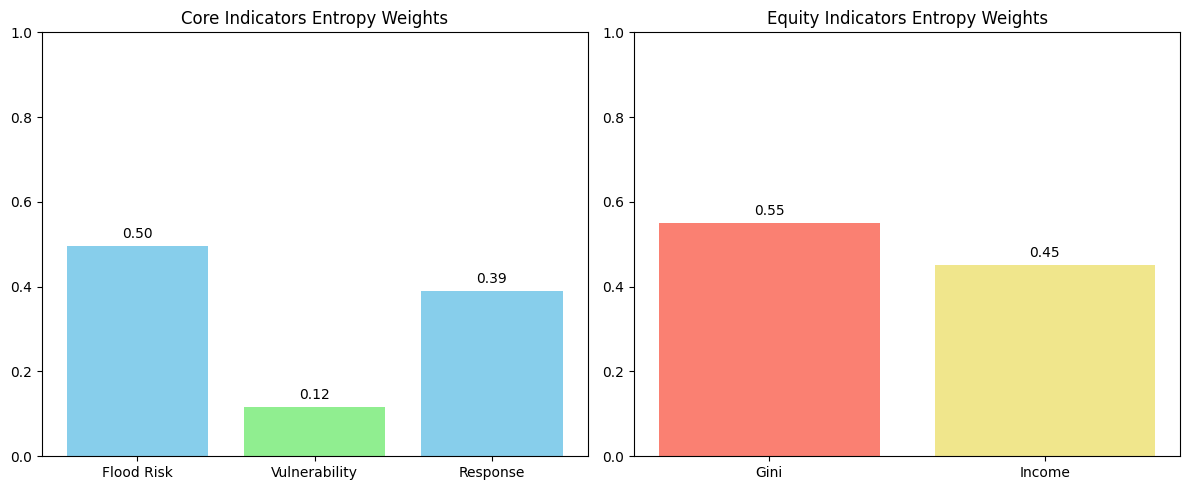

In [11]:
# Visualize entropy weights

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot core weights
ax1.bar(['Flood Risk', 'Vulnerability', 'Response'], list(core_weights.values()), color=['skyblue', 'lightgreen'])
ax1.set_title('Core Indicators Entropy Weights')
ax1.set_ylim(0, 1)
for i, v in enumerate(core_weights.values()):
    ax1.text(i, v + 0.02, f'{v:.2f}', ha='center')

# Plot equity weights
ax2.bar(['Gini', 'Income'], list(equity_weights.values()), color=['salmon', 'khaki'])
ax2.set_title('Equity Indicators Entropy Weights')
ax2.set_ylim(0, 1)
for i, v in enumerate(equity_weights.values()):
    ax2.text(i, v + 0.02, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

# Add this new priority score to the grid_gdf
grid_gdf['entropy_priority'] = priority_norm

In [12]:
grid_gdf["core_score"] = core_score_norm
grid_gdf["composite_index"] = priority_norm
grid_gdf["equity_score"] = equity_score
grid_gdf["all_score"] = all_score_norm

In [13]:
grid_gdf[
    ["composite_index", "core_score", "equity_score", "all_score"]
].describe()

,composite_index,core_score,equity_score,all_score
count,2965.000000,2965.000000,2965.000000,2965.000000
mean,0.304570,0.329789,0.594637,0.371922
std,0.199682,0.210781,0.310977,0.232058
min,0.000000,0.000000,0.000000,0.000000
25%,0.154579,0.166430,0.397049,0.232003
50%,0.237682,0.253056,0.661916,0.279212
75%,0.405932,0.464647,0.713529,0.473160
max,1.000000,1.000000,1.000000,1.000000


# 6. Polar Plot for a Random Zone

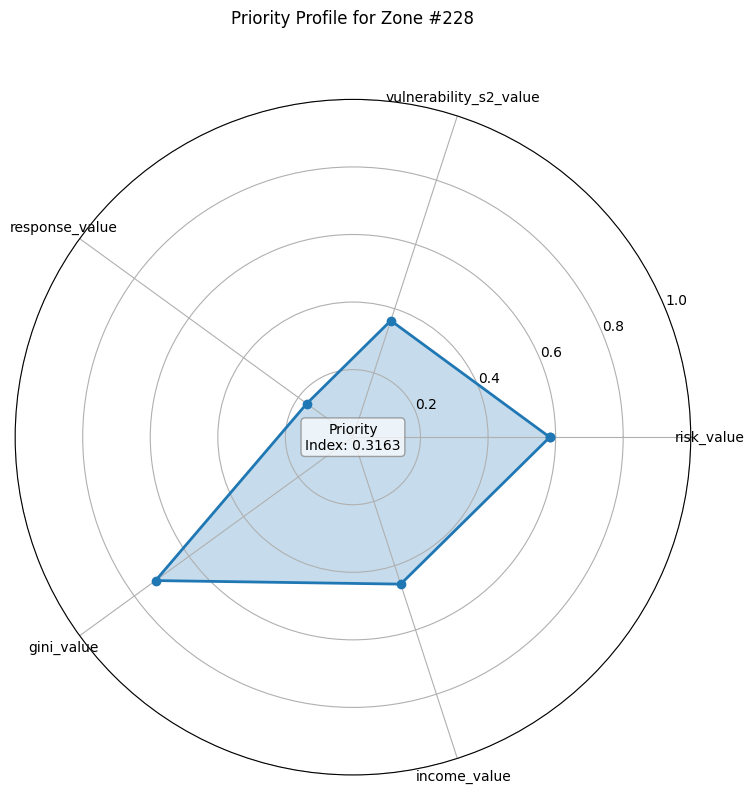

Zone Details:
Risk_value: 0.5826
Vulnerability_s2_value: 0.3629
Response_value: 0.1691
Gini_value: 0.7222
Income_value: 0.4574
Priority Index: 0.3163


In [15]:
# Select a random zone
# Use a different seed each time for different results
np.random.seed(None)  # Use system time as seed
random_zone_idx = 228# np.random.randint(0, len(grid_gdf))
random_zone = grid_gdf.iloc[random_zone_idx]  # 129 228 499 670 99

# Extract the values for the polar plot
features = [
    "risk_value",
    "vulnerability_s2_value",
    "response_value",
    "gini_value",
    "income_value",
]

feature_values = [random_zone[feature] for feature in features]

# Create figure and polar subplot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Number of variables
N = len(features)

# Compute angle for each feature (in radians)
angles = [n / float(N) * 2 * np.pi for n in range(N)]

# Make the plot circular by repeating the first value
feature_values += [feature_values[0]]
angles += [angles[0]]

# Plot data
ax.plot(angles, feature_values, 'o-', linewidth=2)

# Fill area
ax.fill(angles, feature_values, alpha=0.25)

# Set labels for each axis
plt.xticks(angles[:-1], features)

# Add title
plt.title(f'Priority Profile for Zone #{random_zone_idx}', y=1.1)

# Set y axis limits
plt.ylim(0, 1)

# Annotate composite index in the center
ax.annotate(f'Priority\nIndex: {random_zone["composite_index"]:.4f}',
           (0, 0), xytext=(0, 0), 
           textcoords='offset points', ha='center', va='center',
           bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round'))

# Add grid
ax.grid(True)

plt.tight_layout()
plt.show()

# Print zone details
print(f"Zone Details:")
for feature in features:
    print(f"{feature.capitalize()}: {random_zone[feature]:.4f}")
print(f"Priority Index: {random_zone['composite_index']:.4f}")

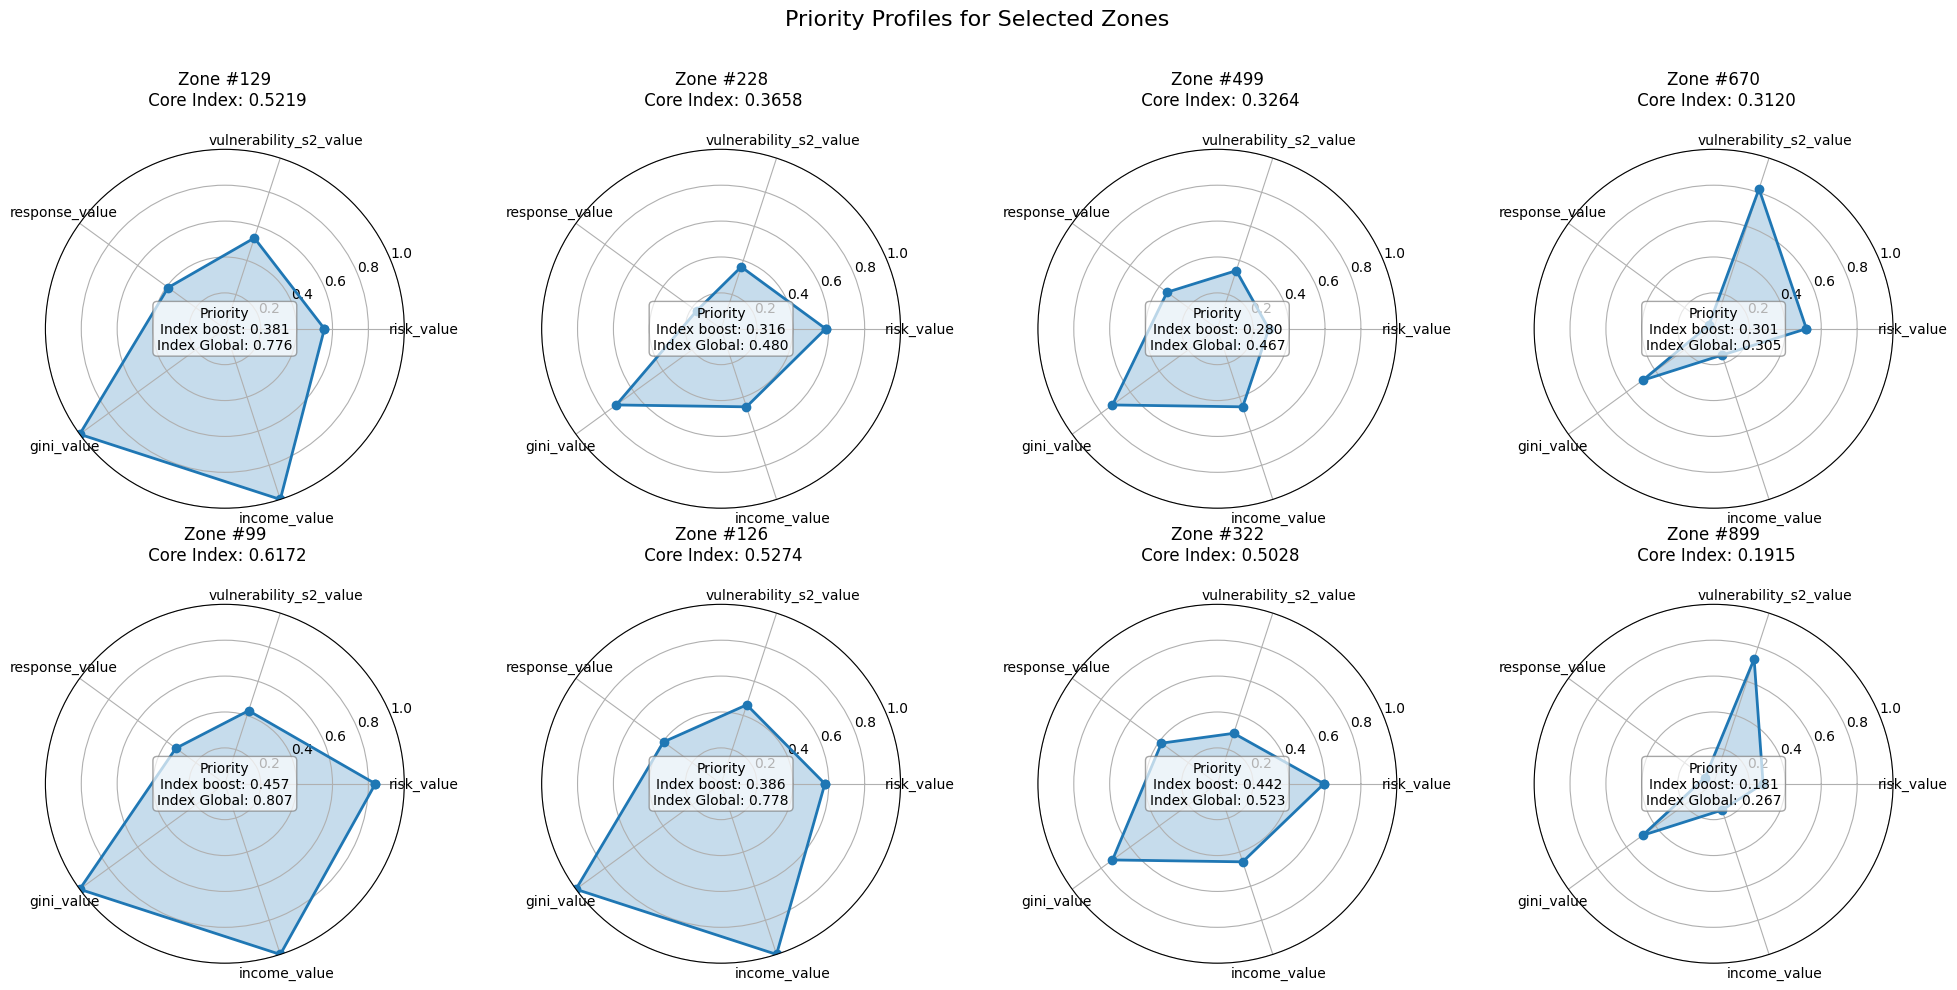

In [16]:
# Plot the radar charts for multiple zones side by side
def plot_radar_chart(zones):
    # Calculate number of rows needed (max 4 plots per row)
    n_plots = len(zones)
    n_cols = min(4, n_plots)  # Maximum 4 plots per row
    n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

    # Create figure
    fig = plt.figure(figsize=(5*n_cols, 5*n_rows))

    # Plot each zone
    for i, zone in enumerate(zones):
        random_zone = grid_gdf.iloc[zone]

        # Create subplot
        ax = fig.add_subplot(n_rows, n_cols, i+1, projection='polar')

        # Extract values for polar plot
        feature_values = [random_zone[feature] for feature in features]
        feature_values += [feature_values[0]]  # Close the loop

        # Compute angles
        angles = [n / float(N) * 2 * np.pi for n in range(N)]
        angles += [angles[0]]  # Close the loop

        # Plot data
        ax.plot(angles, feature_values, 'o-', linewidth=2)
        ax.fill(angles, feature_values, alpha=0.25)

        # Set labels for each axis
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(features)

        # Set title and limits
        ax.set_title(
            f'Zone #{zone}\n Core Index: {random_zone["core_score"]:.4f}',
            size=12,
            y=1.1,
        )
        ax.set_ylim(0, 1)

        # Annotate composite index in the center
        ax.annotate(
            f'Priority\nIndex boost: {random_zone["composite_index"]:.3f}\nIndex Global: {random_zone["core_weighted_sum"]:.3f}',
            (0, 0),
            xytext=(0, 0),
            textcoords="offset points",
            ha="center",
            va="center",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray", boxstyle="round"),
        )

        # Add grid
        ax.grid(True)

    plt.suptitle("Priority Profiles for Selected Zones", size=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Make room for suptitle
    plt.show()

# Plot radar charts for selected zones
plot_radar_chart([129, 228, 499, 670, 99, 126, 322, 899])

In [17]:
# Normalize the composite index into 5 levels
def normalize_priority_index(index):
    if index < 0.2:
        return 1
    elif index < 0.4:
        return 2
    elif index < 0.6:
        return 3
    elif index < 0.8:
        return 4
    else:
        return 5
# Apply normalization
grid_gdf["priority_level"] = grid_gdf["composite_index"].apply(normalize_priority_index)

In [18]:
grid_gdf[["priority_level", "composite_index"]]

,priority_level,composite_index
0,3,0.463438
1,2,0.331853
2,2,0.387334
3,4,0.634292
4,4,0.633789
...,...,...
2960,2,0.232673
2961,1,0.182237
2962,2,0.220972
2963,2,0.216276


Total zones in Porto: 2965
Calculating priority scores for different gamma values...
Processed gamma = 0.00
Processed gamma = 0.25
Processed gamma = 0.50
Processed gamma = 0.75
Processed gamma = 1.00
Creating visualization...


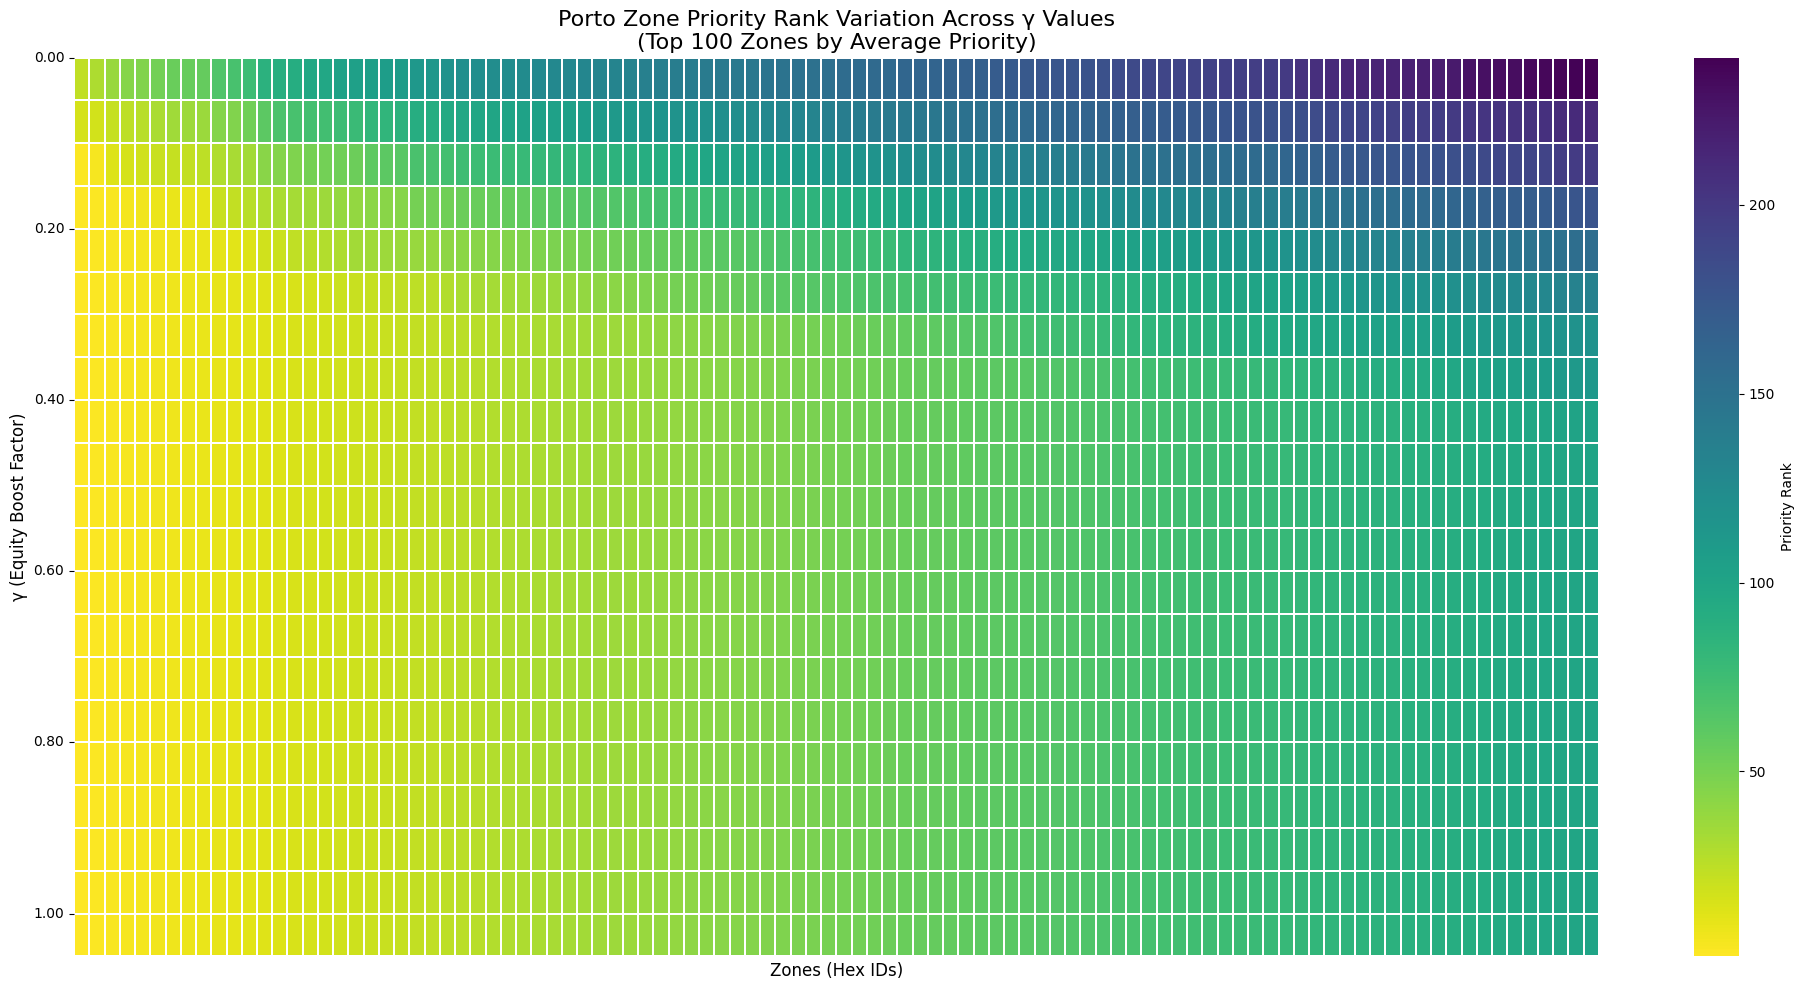


Ranking Variation Analysis for Porto:
Total zones analyzed: 2965
Gamma range: 0.00 to 1.00

Ranking Stability:
- Zones with most stable rankings (low std): [1371, 1835, 1860, 1861, 1862]
- Zones with most volatile rankings (high std): [56, 2427, 2353, 2410, 2384]
- Average ranking standard deviation: 57.68
- Maximum ranking change: 269.45 positions


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Use actual data from the multilayer assessment
print(f"Total zones in {city}: {len(grid_gdf)}")

# Extract actual core and equity scores from your data
actual_core_scores = grid_gdf["core_score"].values
actual_equity_scores = grid_gdf["equity_score"].values
zone_ids = grid_gdf["hex_id"].values

# Define gamma sweep with more granular steps
gamma_values = np.linspace(0, 1, num=21)  # More detailed analysis

# DataFrame to hold ranking positions
rankings = pd.DataFrame({"Zone": zone_ids})

print("Calculating priority scores for different gamma values...")
for i, gamma in enumerate(gamma_values):
    # Use your actual priority calculation formula
    priority_scores = actual_core_scores * (1 + gamma * actual_equity_scores)
    
    # Normalize the priority scores
    priority_scores_norm = (priority_scores - priority_scores.min()) / (priority_scores.max() - priority_scores.min())
    
    temp_df = (
        pd.DataFrame({"Zone": zone_ids, f"Priority_γ={gamma:.2f}": priority_scores_norm})
        .sort_values(by=f"Priority_γ={gamma:.2f}", ascending=False)
        .reset_index(drop=True)
    )
    temp_df[f"Rank_γ={gamma:.2f}"] = temp_df.index + 1
    rankings = rankings.merge(temp_df[["Zone", f"Rank_γ={gamma:.2f}"]], on="Zone")
    
    if i % 5 == 0:  # Progress indicator
        print(f"Processed gamma = {gamma:.2f}")

print("Creating visualization...")

# Select a subset of zones for better visualization (top 100 by average ranking)
rank_cols = [col for col in rankings.columns if col.startswith("Rank_")]
rankings['avg_rank'] = rankings[rank_cols].mean(axis=1)
top_zones = rankings.nsmallest(100, 'avg_rank')

# Reshape for heatmap (using subset)
rank_matrix = top_zones.set_index("Zone")[rank_cols].T
rank_matrix.index.name = "Gamma"

# Plot heatmap of ranking variation
plt.figure(figsize=(20, 10))
sns.heatmap(
    rank_matrix.astype(float), 
    cmap="viridis_r", 
    cbar_kws={"label": "Priority Rank"}, 
    linewidths=0.02,
    xticklabels=False  # Too many zones to show labels
)
plt.title(f"{city} Zone Priority Rank Variation Across γ Values\n(Top 100 Zones by Average Priority)", fontsize=16)
plt.xlabel("Zones (Hex IDs)", fontsize=12)
plt.ylabel("γ (Equity Boost Factor)", fontsize=12)

# Customize y-axis to show gamma values more clearly
ytick_positions = np.arange(0, len(gamma_values), 4)
ytick_labels = [f"{gamma_values[i]:.2f}" for i in ytick_positions]
plt.yticks(ytick_positions, ytick_labels)

plt.tight_layout()
plt.show()

# Show statistics about ranking changes
print(f"\nRanking Variation Analysis for {city}:")
print(f"Total zones analyzed: {len(rankings)}")
print(f"Gamma range: {gamma_values.min():.2f} to {gamma_values.max():.2f}")

# Calculate ranking stability metrics
rank_std = rankings[rank_cols].std(axis=1)
print(f"\nRanking Stability:")
print(f"- Zones with most stable rankings (low std): {rank_std.nsmallest(5).index.tolist()}")
print(f"- Zones with most volatile rankings (high std): {rank_std.nlargest(5).index.tolist()}")
print(f"- Average ranking standard deviation: {rank_std.mean():.2f}")
print(f"- Maximum ranking change: {rank_std.max():.2f} positions")